In [52]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import seaborn as sns

In [3]:
df = pd.read_csv("../../../datasets/Titanic-Dataset.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df.isnull().mean() #To find how much data is actually missing

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

In [9]:
# Splitting the data into test and train dataset

from sklearn.model_selection import train_test_split

In [10]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state =2, stratify = y)

In [16]:
X_train.shape, X_test.shape

((712, 11), (179, 11))

In [17]:
X_train.isnull().mean()

PassengerId    0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.202247
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.762640
Embarked       0.002809
dtype: float64

In [19]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

In [22]:
# Since Cabin and Embarked in categorical data therefore we wont apply mean, median imputation on them
X_train['Cabin'], X_train['Embarked']

(847                NaN
 822                NaN
 27         C23 C25 C27
 433                NaN
 300                NaN
             ...       
 627                 D9
 547                NaN
 829                B28
 424                NaN
 742    B57 B59 B63 B66
 Name: Cabin, Length: 712, dtype: object,
 847      C
 822      S
 27       S
 433      S
 300      Q
       ... 
 627      S
 547      C
 829    NaN
 424      S
 742      C
 Name: Embarked, Length: 712, dtype: object)

In [23]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

In [24]:
X_train.sample(5)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_median,Age_mean
787,788,3,"Rice, Master. George Hugh",male,8.0,4,1,382652,29.1250,NaN,Q,8.0,8.00000
431,432,3,"Thorneycroft, Mrs. Percival (Florence Kate White)",female,NaN,1,0,376564,16.1000,NaN,S,28.0,29.72507
421,422,3,"Charters, Mr. David",male,21.0,0,0,A/5. 13032,7.7333,NaN,Q,21.0,21.00000
600,601,2,"Jacobsohn, Mrs. Sidney Samuel (Amy Frances Chr...",female,24.0,2,1,243847,27.0000,NaN,S,24.0,24.00000
795,796,2,"Otter, Mr. Richard",male,39.0,0,0,28213,13.0000,NaN,S,39.0,39.00000


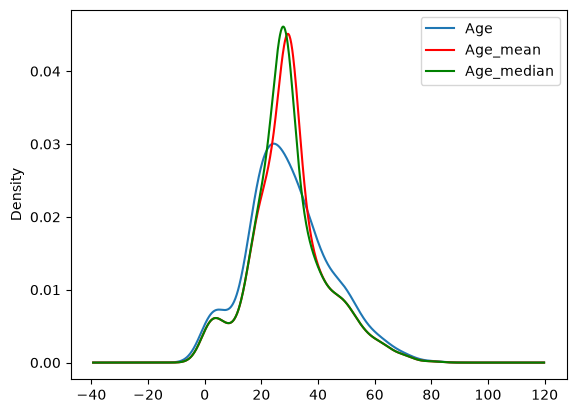

In [30]:
fig = plt.figure()
ax = fig.add_subplot(111)

#Original Variable distribution
X_train['Age'].plot(kind = 'kde', ax = ax)

#Variable imputed with mean
X_train['Age_mean'].plot(kind = 'kde', ax = ax, color = 'red')

#Variable imputed with median
X_train['Age_median'].plot(kind = 'kde', ax = ax, color = 'green')

#Add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels, loc = 'best')

# We can see that the age_mean deviates heavily from the actual age therefore it is advisable to not use mean or median when it changes the distribution heavily 

**Using Sklearn**

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state =2, stratify = y)

In [34]:
imputer1 =SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [35]:
imputer1.fit_transform(X_train)
#This gives an error because not all the data in our dataset is in numerial form

ValueError: Cannot use median strategy with non-numeric data:
could not convert string to float: 'Markoff, Mr. Marin'

In [51]:
# Identify the columns that dont need imputing:
# PassengerId, Name, and Ticket usually don't need imputation
num_cols = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']

transformer = ColumnTransformer(transformers = [('num_imputer',SimpleImputer(strategy = 'mean'),num_cols)], remainder = 'passthrough', verbose_feature_names_out = False)
X_train_transformed = transformer.fit_transform(X_train)

# This is to get the new order of all columns
all_columns = transformer.get_feature_names_out()

# Convert the Numpy array back into a readable format
X_train_cleaned = pd.DataFrame(X_train_transformed, columns = all_columns)

#View the complete data
X_train_cleaned.head()

,Age,Fare,Pclass,SibSp,Parch,PassengerId,Name,Sex,Ticket,Cabin,Embarked
0,35.0,7.8958,3.0,0.0,0.0,848,"Markoff, Mr. Marin",male,349213,NaN,C
1,38.0,0.0,1.0,0.0,0.0,823,"Reuchlin, Jonkheer. John George",male,19972,NaN,S
2,19.0,263.0,1.0,3.0,2.0,28,"Fortune, Mr. Charles Alexander",male,19950,C23 C25 C27,S
3,17.0,7.125,3.0,0.0,0.0,434,"Kallio, Mr. Nikolai Erland",male,STON/O 2. 3101274,NaN,S
4,29.72507,7.75,3.0,0.0,0.0,301,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,9234,NaN,Q


In [53]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [54]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_imputed
847,848,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C,35.0
822,823,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S,38.0
27,28,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,19.0
433,434,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S,17.0
300,301,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q,NaN


In [55]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()]

300   NaN
359   NaN
158   NaN
680   NaN
241   NaN
       ..
107   NaN
613   NaN
718   NaN
46    NaN
547   NaN
Name: Age_imputed, Length: 144, dtype: float64

In [56]:
X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
X_test['Age_imputed'][X_test['Age_imputed'].isnull()] = X_test['Age'].dropna().sample(X_test['Age'].isnull().sum()).values

C:\Users\laksh\AppData\Local\Temp\ipykernel_8216\1252176479.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['Age_imputed'][X_train['Age_imputed'].isnull()] = X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values
C:

In [64]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24. , 26. , 21. , 28. , 29. , 30. , 23.5, 61. , 36. , 47. ,  4. ,
       48. , 40.5, 55. , 19. , 30. , 16. , 26. , 52. , 58. , 51. ,  7. ,
       38. , 20. , 25. , 14. , 20. , 18. , 31. , 30.5, 56. ,  4. , 27. ,
       18. , 36. , 35. , 35. , 29. , 24. , 16. , 28. , 17. ,  1. , 29. ,
       21. , 20. , 26. , 51. , 57. , 28. , 42. , 16. ,  5. , 36. , 37. ,
       47. , 32. , 11. , 45. , 34. ,  6. ,  8. , 43. , 52. , 32. , 22. ,
       28. , 26. , 31. , 44. , 33. , 17. , 54. , 25. , 24. , 54. , 24. ,
       30. , 45.5, 31. , 34. , 33. , 47. , 27. , 37. , 57. , 43. ,  1. ,
        2. , 30. , 34. , 26. , 30. , 34.5, 43. , 23. , 35. , 29. , 54. ,
       21. , 25. , 26. , 35. , 36. , 14. , 15. , 24. , 51. , 26. , 40. ,
       39. , 21. , 33. , 25. , 42. ,  1. , 24. , 26. , 11. ,  4. , 20. ,
       23. , 60. , 64. , 27. , 24. , 29. , 49. , 71. , 22. , 39. , 27. ,
       23. , 40. ,  6. , 65. ,  1. , 28.5, 27. , 32. , 24. , 23. , 25. ,
       30. ])

In [65]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_imputed
847,848,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C,35.0
822,823,1,"Reuchlin, Jonkheer. John George",male,38.0,0,0,19972,0.0000,NaN,S,38.0
27,28,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S,19.0
433,434,3,"Kallio, Mr. Nikolai Erland",male,17.0,0,0,STON/O 2. 3101274,7.1250,NaN,S,17.0
300,301,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q,47.0
